In [1]:
# ============================================================
# PLANT HEALTH MODEL - BALANCED DATASET
# ============================================================
#
# BINARY CLASSIFICATION
# 0 = Healthy
# 1 = Unhealthy
#
# MODEL:
# ResNet18 Transfer Learning
#
# DATASET:
# NEWPlantVillage-Dataset
#
# ============================================================

import os
import random
import time

import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import models, transforms

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from collections import Counter

In [2]:
# ============================================================
# 2. CONFIGURATION
# ============================================================

BASE_DIR = r"F:\Capstone project\module 3 tree Health"

# NEW BALANCED DATASET
DATASET_DIR = r"F:\Capstone project\module 3 tree Health\NEWPlantVillage-Dataset"

# Model save location
MODEL_PATH = os.path.join(
    BASE_DIR,
    "new-plant_health_resnet18_balanced.pth"
)

# ============================================================
# EXTERNAL IMAGE
# CHANGE THIS TO A REAL IMAGE FILE
# ============================================================

EXTERNAL_IMAGE = r"F:\Capstone project\module 3 tree Health\test\healthy.jpg"


# ============================================================
# TRAINING PARAMETERS
# ============================================================

BATCH_SIZE = 32

EPOCHS = 15

LEARNING_RATE = 0.0001

SEED = 42


# ============================================================
# CLASS NAMES
# ============================================================

CLASS_NAMES = [
    "Healthy",
    "Unhealthy"
]


# ============================================================
# RANDOM SEED
# ============================================================

random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
# ============================================================
# 3. DEVICE INFORMATION
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("DEVICE INFORMATION")
print("=" * 70)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Using device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )

DEVICE INFORMATION
PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU memory: 6.0 GB


In [4]:
# ============================================================
# 4. CHECK DATASET
# ============================================================

print("=" * 70)
print("CHECKING NEW DATASET")
print("=" * 70)

print("Dataset path:")
print(DATASET_DIR)

if not os.path.exists(DATASET_DIR):

    raise FileNotFoundError(
        f"\nDataset not found:\n{DATASET_DIR}"
    )

print("\nDataset found!")

print("\nContents:")

for item in sorted(os.listdir(DATASET_DIR)):

    item_path = os.path.join(
        DATASET_DIR,
        item
    )

    if os.path.isdir(item_path):

        print(
            "Folder:",
            item
        )

CHECKING NEW DATASET
Dataset path:
F:\Capstone project\module 3 tree Health\NEWPlantVillage-Dataset

Dataset found!

Contents:
Folder: Healthy
Folder: Unhealthy


In [5]:
# ============================================================
# 5. CHECK CLASS DISTRIBUTION
# ============================================================

HEALTHY_DIR = os.path.join(
    DATASET_DIR,
    "Healthy"
)

UNHEALTHY_DIR = os.path.join(
    DATASET_DIR,
    "Unhealthy"
)


if not os.path.exists(HEALTHY_DIR):

    raise FileNotFoundError(
        f"Healthy folder not found:\n{HEALTHY_DIR}"
    )


if not os.path.exists(UNHEALTHY_DIR):

    raise FileNotFoundError(
        f"Unhealthy folder not found:\n{UNHEALTHY_DIR}"
    )


VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


def count_images(folder):

    return sum(
        1
        for filename in os.listdir(folder)
        if filename.lower().endswith(
            VALID_EXTENSIONS
        )
    )


healthy_count = count_images(
    HEALTHY_DIR
)

unhealthy_count = count_images(
    UNHEALTHY_DIR
)


print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

print(
    "Healthy:",
    healthy_count
)

print(
    "Unhealthy:",
    unhealthy_count
)

print(
    "Total:",
    healthy_count + unhealthy_count
)

CLASS DISTRIBUTION
Healthy: 15084
Unhealthy: 15084
Total: 30168


In [6]:
# ============================================================
# 6. CUSTOM DATASET
# ============================================================

class PlantHealthDataset(Dataset):

    def __init__(
        self,
        root_dir,
        transform=None
    ):

        self.root_dir = root_dir
        self.transform = transform

        self.samples = []


        # ====================================================
        # HEALTHY = 0
        # ====================================================

        healthy_dir = os.path.join(
            root_dir,
            "Healthy"
        )

        for filename in os.listdir(
            healthy_dir
        ):

            if filename.lower().endswith(
                VALID_EXTENSIONS
            ):

                image_path = os.path.join(
                    healthy_dir,
                    filename
                )

                self.samples.append(
                    (
                        image_path,
                        0
                    )
                )


        # ====================================================
        # UNHEALTHY = 1
        # ====================================================

        unhealthy_dir = os.path.join(
            root_dir,
            "Unhealthy"
        )

        for filename in os.listdir(
            unhealthy_dir
        ):

            if filename.lower().endswith(
                VALID_EXTENSIONS
            ):

                image_path = os.path.join(
                    unhealthy_dir,
                    filename
                )

                self.samples.append(
                    (
                        image_path,
                        1
                    )
                )


    def __len__(self):

        return len(
            self.samples
        )


    def __getitem__(
        self,
        index
    ):

        image_path, label = self.samples[index]


        image = Image.open(
            image_path
        ).convert("RGB")


        if self.transform:

            image = self.transform(
                image
            )


        return image, label

In [7]:
# ============================================================
# 7. IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# VALIDATION / TEST
# ============================================================

test_transform = transforms.Compose([

    transforms.Resize(
        (224, 224)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

In [8]:
# ============================================================
# 8. CREATE DATASET
# ============================================================

print("=" * 70)
print("LOADING BALANCED DATASET")
print("=" * 70)


# Dataset used for finding samples
base_dataset = PlantHealthDataset(
    DATASET_DIR,
    transform=None
)


# Training version
train_full_dataset = PlantHealthDataset(
    DATASET_DIR,
    transform=train_transform
)


# Validation/test version
test_full_dataset = PlantHealthDataset(
    DATASET_DIR,
    transform=test_transform
)


print(
    "Total images:",
    len(base_dataset)
)


# ============================================================
# CHECK LABEL DISTRIBUTION
# ============================================================

labels = [
    label
    for _, label in base_dataset.samples
]


label_counts = Counter(
    labels
)


print("\nClass distribution:")

print(
    "Healthy:",
    label_counts[0]
)

print(
    "Unhealthy:",
    label_counts[1]
)

LOADING BALANCED DATASET
Total images: 30168

Class distribution:
Healthy: 15084
Unhealthy: 15084


In [9]:
# ============================================================
# 9. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

indices = list(
    range(
        len(base_dataset)
    )
)

labels = [
    label
    for _, label in base_dataset.samples
]


# ============================================================
# FIRST:
# 70% TRAIN
# 30% TEMP
# ============================================================

train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)


# ============================================================
# SECOND:
# TEMP -> 15% VALIDATION + 15% TEST
# ============================================================

temp_labels = [
    labels[i]
    for i in temp_indices
]


val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)


# ============================================================
# CREATE SUBSETS
# ============================================================

train_dataset = Subset(
    train_full_dataset,
    train_indices
)

val_dataset = Subset(
    test_full_dataset,
    val_indices
)

test_dataset = Subset(
    test_full_dataset,
    test_indices
)


# ============================================================
# PRINT SPLIT
# ============================================================

print("=" * 70)
print("DATA SPLIT")
print("=" * 70)

print(
    "Training:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Testing:",
    len(test_dataset)
)

DATA SPLIT
Training: 21117
Validation: 4525
Testing: 4526


In [10]:
# ============================================================
# 10. VERIFY SPLIT BALANCE
# ============================================================

def count_subset_labels(
    subset,
    original_dataset
):

    counts = Counter()

    for idx in subset.indices:

        label = original_dataset.samples[idx][1]

        counts[label] += 1

    return counts


train_counts = count_subset_labels(
    train_dataset,
    base_dataset
)

val_counts = count_subset_labels(
    val_dataset,
    base_dataset
)

test_counts = count_subset_labels(
    test_dataset,
    base_dataset
)


print("=" * 70)
print("SPLIT CLASS DISTRIBUTION")
print("=" * 70)

print("\nTRAIN")
print("Healthy:", train_counts[0])
print("Unhealthy:", train_counts[1])

print("\nVALIDATION")
print("Healthy:", val_counts[0])
print("Unhealthy:", val_counts[1])

print("\nTEST")
print("Healthy:", test_counts[0])
print("Unhealthy:", test_counts[1])

SPLIT CLASS DISTRIBUTION

TRAIN
Healthy: 10558
Unhealthy: 10559

VALIDATION
Healthy: 2263
Unhealthy: 2262

TEST
Healthy: 2263
Unhealthy: 2263


In [11]:
# ============================================================
# 11. DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


print("=" * 70)
print("DATALOADERS READY")
print("=" * 70)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

DATALOADERS READY
Training batches: 660
Validation batches: 142
Testing batches: 142


In [12]:
# ============================================================
# 12. LOAD RESNET18
# ============================================================

print("=" * 70)
print("LOADING RESNET18")
print("=" * 70)


model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)


# ============================================================
# FREEZE EVERYTHING
# ============================================================

for parameter in model.parameters():

    parameter.requires_grad = False


# ============================================================
# UNFREEZE FINAL RESNET BLOCK
# ============================================================

for parameter in model.layer4.parameters():

    parameter.requires_grad = True


# ============================================================
# REPLACE FINAL CLASSIFIER
# ============================================================

model.fc = nn.Sequential(

    nn.Dropout(
        p=0.3
    ),

    nn.Linear(
        model.fc.in_features,
        2
    )
)


model = model.to(device)


print("\nModel ready.")

print(
    "Classes:",
    CLASS_NAMES
)

print(
    "Output:",
    2
)

LOADING RESNET18

Model ready.
Classes: ['Healthy', 'Unhealthy']
Output: 2


In [13]:
# ============================================================
# 13. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(

    [
        {
            "params": model.layer4.parameters(),
            "lr": 1e-4
        },

        {
            "params": model.fc.parameters(),
            "lr": 5e-4
        }
    ],

    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2
)


print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0.0001
)


In [14]:
# ============================================================
# 14. TRAIN MODEL
# ============================================================

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0


print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)


for epoch in range(EPOCHS):

    start_time = time.time()


    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad()


        outputs = model(
            images
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()


        running_loss += loss.item()


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()


    train_loss = (
        running_loss /
        len(train_loader)
    )


    train_accuracy = (
        100.0 *
        correct /
        total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0

    val_correct = 0

    val_total = 0


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(
                images
            )


            loss = criterion(
                outputs,
                labels
            )


            val_running_loss += loss.item()


            predictions = torch.argmax(
                outputs,
                dim=1
            )


            val_total += labels.size(0)

            val_correct += (
                predictions == labels
            ).sum().item()


    val_loss = (
        val_running_loss /
        len(val_loader)
    )


    val_accuracy = (
        100.0 *
        val_correct /
        val_total
    )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_accuracies.append(
        val_accuracy
    )


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step(
        val_accuracy
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        saved = " <-- BEST MODEL SAVED"

    else:

        saved = ""


    elapsed = (
        time.time() -
        start_time
    )


    current_lr = optimizer.param_groups[0]["lr"]


    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.2f}% "
        f"| LR: {current_lr:.6f} "
        f"| Time: {elapsed:.1f}s"
        f"{saved}"
    )

STARTING TRAINING
Epoch [02/15] | Train Loss: 0.0224 | Train Acc: 99.22% | Val Loss: 0.0105 | Val Acc: 99.65% | LR: 0.000100 | Time: 202.1s <-- BEST MODEL SAVED
Epoch [03/15] | Train Loss: 0.0180 | Train Acc: 99.43% | Val Loss: 0.0111 | Val Acc: 99.65% | LR: 0.000100 | Time: 182.9s
Epoch [05/15] | Train Loss: 0.0091 | Train Acc: 99.67% | Val Loss: 0.0116 | Val Acc: 99.62% | LR: 0.000050 | Time: 177.7s
Epoch [06/15] | Train Loss: 0.0061 | Train Acc: 99.82% | Val Loss: 0.0057 | Val Acc: 99.67% | LR: 0.000050 | Time: 165.3s <-- BEST MODEL SAVED
Epoch [07/15] | Train Loss: 0.0042 | Train Acc: 99.86% | Val Loss: 0.0056 | Val Acc: 99.80% | LR: 0.000050 | Time: 165.1s <-- BEST MODEL SAVED
Epoch [08/15] | Train Loss: 0.0046 | Train Acc: 99.82% | Val Loss: 0.0040 | Val Acc: 99.85% | LR: 0.000050 | Time: 164.6s <-- BEST MODEL SAVED
Epoch [09/15] | Train Loss: 0.0030 | Train Acc: 99.91% | Val Loss: 0.0131 | Val Acc: 99.60% | LR: 0.000050 | Time: 164.6s
Epoch [10/15] | Train Loss: 0.0029 | Train A

In [15]:
# ============================================================
# 15. LOAD BEST MODEL
# ============================================================

print("=" * 70)
print("LOADING BEST MODEL")
print("=" * 70)


model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)


model.eval()


print(
    "Best validation accuracy:",
    f"{best_val_accuracy:.2f}%"
)


print(
    "Model saved at:",
    MODEL_PATH
)

LOADING BEST MODEL
Best validation accuracy: 99.89%
Model saved at: F:\Capstone project\module 3 tree Health\new-plant_health_resnet18_balanced.pth


In [16]:
# ============================================================
# 16. TEST MODEL
# ============================================================

print("=" * 70)
print("TESTING MODEL")
print("=" * 70)


all_labels = []

all_predictions = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images
        )


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )


# ============================================================
# TEST ACCURACY
# ============================================================

correct = sum(

    prediction == label

    for prediction, label

    in zip(
        all_predictions,
        all_labels
    )
)


test_accuracy = (
    100.0 *
    correct /
    len(all_labels)
)


print(
    f"\nTest Accuracy: "
    f"{test_accuracy:.2f}%"
)

TESTING MODEL

Test Accuracy: 99.93%


In [17]:
# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)


print(
    classification_report(

        all_labels,

        all_predictions,

        target_names=CLASS_NAMES,

        digits=4
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy     0.9996    0.9991    0.9993      2263
   Unhealthy     0.9991    0.9996    0.9993      2263

    accuracy                         0.9993      4526
   macro avg     0.9993    0.9993    0.9993      4526
weighted avg     0.9993    0.9993    0.9993      4526



CONFUSION MATRIX
[[2261    2]
 [   1 2262]]


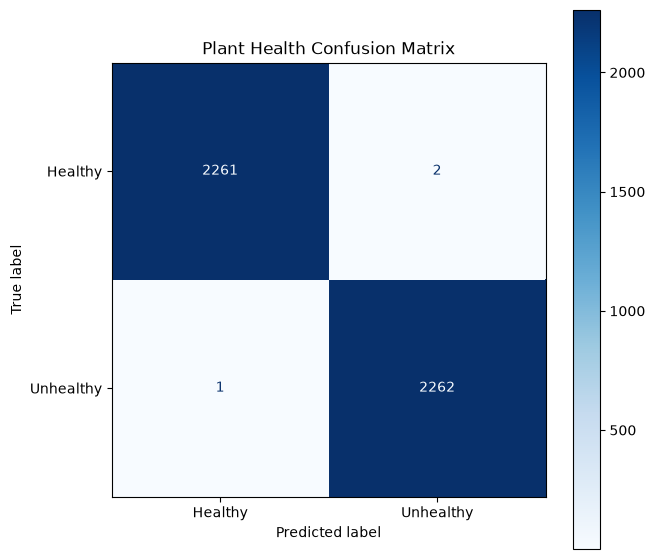

In [18]:
# ============================================================
# 18. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_predictions
)


print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Healthy",
        "Unhealthy"
    ]
)


fig, ax = plt.subplots(
    figsize=(7, 7)
)


disp.plot(
    ax=ax,
    cmap="Blues"
)


plt.title(
    "Plant Health Confusion Matrix"
)


plt.show()